### A dataclass schema is a Python dataclass that defines the expected fields and data types for structured output from an LLM.

In [6]:
from typing_extensions import TypedDict
from typing import Literal

class TypeDictClass(TypedDict):
    name:str
    game:Literal["cricket","football"]
    

In [7]:
def play_game(state:TypeDictClass):
    print("-------Play Game Node Has BEEn Called --------")
    return{
        "name":state["name"] + "wants to play"
    }

def cricket(state:TypeDictClass):
    print("----------Cricket Node Has Been Called")   
    return{
        "game":"cricket"
    }
def football(state:TypeDictClass):
    print("----------Football Node Has Been Called")   
    return{
        "game":"football"
    }

In [8]:
import random
def decide_play(state:TypeDictClass)-> Literal["cricket","football"]:
    
    print("-----Decide Play node has Been Called")
    if random.random()< 0.5:
        return "cricket"
    else:
        return "football"

In [9]:

from IPython.display import display,Image
from langgraph.graph import StateGraph,START,END

In [10]:
builder = StateGraph(TypeDictClass)
builder.add_node("play_game",play_game)
builder.add_node("cricket",cricket)
builder.add_node("football",football)
builder.add_edge(START,"play_game")
builder.add_conditional_edges("play_game",decide_play)
builder.add_edge("cricket",END)
builder.add_edge("football",END)


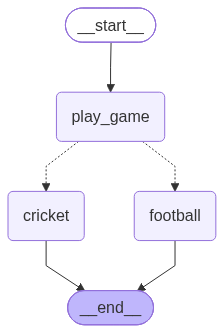

In [11]:
graph = builder.compile()
display(Image(graph.get_graph().draw_mermaid_png()))

In [14]:
graph.invoke({"name":"picardooo "})

-------Play Game Node Has BEEn Called --------
-----Decide Play node has Been Called
----------Cricket Node Has Been Called


{'name': 'picardooo wants to play', 'game': 'cricket'}

In [15]:
from dataclasses import dataclass

@dataclass
class DataClassState:
    name:str
    game:Literal["cricket","football"]

In [ ]:
def play_game(state:DataClassState):
    print("-------Play Game Node Has BEEn Called --------")
    return{
        "name":state.name + "wants to play"
    }

def cricket(state:DataClassState):
    print("----------Cricket Node Has Been Called")   
    return{
        "game":"cricket"
    }
def football(state:DataClassState):
    print("----------Football Node Has Been Called")   
    return{
        "game":"football"
    }